<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/04_natural_language_processing/05_word2vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Word2Vec

Word2Vec is a neural network-based algorithm introduced by Google that learns dense vector representations of words from large text corpora.

Unlike Bag of Words and TF-IDF, Word2Vec learns word meanings based on their surrounding context. Words that frequently appear in similar contexts obtain similar vector representations.

Word2Vec has two main architectures:

- Continuous Bag of Words (CBOW): Predicts the target word from surrounding context words.
- Skip-gram: Predicts surrounding context words from the target word.

These learned embeddings capture semantic relationships between words and are widely used in NLP applications.

In [3]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 68.1 MB/s eta 0:00:00


In [4]:
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
sentences = [

    ["machine","learning","is","interesting"],

    ["deep","learning","uses","neural","networks"],

    ["artificial","intelligence","is","the","future"],

    ["machine","learning","powers","ai"],

    ["deep","learning","improves","computer","vision"]

]

In [5]:
model = Word2Vec(

    sentences,

    vector_size=50,

    window=2,

    min_count=1,

    workers=1,

    epochs=100

)

In [6]:
print(model.wv.index_to_key)

['learning', 'deep', 'is', 'machine', 'vision', 'computer', 'improves', 'ai', 'powers', 'future', 'the', 'intelligence', 'artificial', 'networks', 'neural', 'uses', 'interesting']


In [7]:
vector = model.wv["learning"]

print(vector)

[-1.24348071e-03  4.53258690e-04  1.02150831e-02  1.80988722e-02
 -1.87777951e-02 -1.44755831e-02  1.31032495e-02  1.80716310e-02
 -1.03695644e-02 -7.88847078e-03  1.48578314e-02 -3.24466941e-03
 -9.00698639e-03  1.31123569e-02 -9.68664605e-03 -3.54260695e-03
  6.01656409e-03  2.20126193e-03 -1.70195289e-02 -1.91571675e-02
  1.46457851e-02  1.01907542e-02  1.39284898e-02  1.57952087e-03
  1.27490675e-02 -6.79414067e-03 -1.85049349e-03  1.18431496e-02
 -1.52641349e-02 -7.64302071e-03 -1.48562919e-02 -2.12775194e-03
  1.89629290e-02 -1.49786761e-02 -4.73104091e-03 -3.90916830e-03
  1.65489465e-02 -1.18824644e-02  4.10365938e-05 -9.41347517e-03
 -1.89989451e-02  9.89655312e-03 -1.77710466e-02 -8.87104217e-03
  2.29500816e-04 -4.47515107e-04 -1.51902139e-02  1.90921817e-02
  1.00460788e-02  1.85161401e-02]


In [8]:
print(vector.shape)

(50,)


In [9]:
similar_words = model.wv.most_similar("learning")

similar_df = pd.DataFrame(

    similar_words,

    columns=["Word","Similarity"]

)

similar_df

,Word,Similarity
0,neural,0.218851
1,intelligence,0.177470
2,networks,0.159335
3,is,0.137924
4,ai,0.137450
5,future,0.105596
6,interesting,0.059897
7,deep,0.047775
8,artificial,0.047535
9,computer,0.019192


In [10]:
similarity = model.wv.similarity(

    "machine",

    "learning"

)

print(similarity)

-0.012974727


In [11]:
comparison = pd.DataFrame({

    "CBOW":[

        "Predicts target word",

        "Faster training",

        "Better for frequent words"

    ],

    "Skip-gram":[

        "Predicts surrounding words",

        "Slower training",

        "Better for rare words"

    ]

})

comparison

,CBOW,Skip-gram
0,Predicts target word,Predicts surrounding words
1,Faster training,Slower training
2,Better for frequent words,Better for rare words


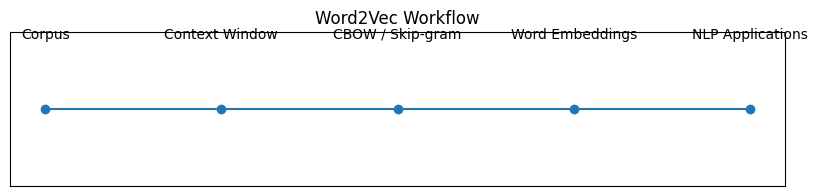

In [12]:
steps = [

    "Corpus",

    "Context Window",

    "CBOW / Skip-gram",

    "Word Embeddings",

    "NLP Applications"

]

plt.figure(figsize=(10,2))

plt.plot(

    range(len(steps)),

    [1]*len(steps),

    marker="o"

)

for i, step in enumerate(steps):

    plt.text(i,1.05,step,ha="center")

plt.xticks([])

plt.yticks([])

plt.title("Word2Vec Workflow")

plt.show()